# Preprocesamiento (scikit-learn) y Modelado (scikit-learn)

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')



In [4]:
datos = pd.read_csv('aceptados.csv')
pd.options.display.float_format = '{:,.2f}'.format
# Creacion variable objetivo
df = datos[datos["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

df = df.drop(columns=["loan_status"])

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")



Filas:    1,345,310
Columnas: 151


## Preprocesamiento (scikit-learn)
En esta sección se eliminarán variables con demasiados valores faltantes, se identifican y eliminan variables que generan data leakage, se seleccionan las variables importantes mediante Mutual Information, se codifican las variables categóricas y se dividen los datos en conjuntos de entrenamiento y prueba


### Selección de variables  
Con esto se quiere reducir la dimensionalidad del dataset eliminando columnas que no aportan información util al modelo

#### Eliminar columnas con alto porcentaje de NA



In [5]:
umbral = 0.25
cols_eliminar = df.columns[df.isnull().mean() > umbral]
df = df.drop(columns=cols_eliminar)

print(f"Columnas eliminadas: {len(cols_eliminar)}")
print(list(cols_eliminar))
print(f"Columnas restantes: {df.shape[1]}")

Columnas eliminadas: 58
['member_id', 'desc', 'mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_leng

Se eliminaron todas las columnas con mas del 25% de valores nulos. Fueron eliminadas 58 columnas reduciendo el dataset de 151 a 93 columnas.

#### Eliminar variables con data leakage

El data leakage ocurre cuando el modelo recibe información que no estaría disponible al momento de hacer una predicción real


In [6]:
leakage = ["recoveries", "collection_recovery_fee", "total_rec_prncp",
    "total_rec_int", "total_rec_late_fee", "last_pymnt_amnt",
    "last_pymnt_d", "next_pymnt_d", "total_pymnt", "total_pymnt_inv",
    "out_prncp", "out_prncp_inv", "debt_settlement_flag",
    "last_credit_pull_d", "issue_d", "last_fico_range_high",
    "last_fico_range_low"]

df = df.drop(columns=[col for col in leakage if col in df.columns])

print(f"Columnas eliminadas por leakage: {len([col for col in leakage if col in df.columns])}")
print(list)
print(f"Columnas restantes: {df.shape[1]}")

Columnas eliminadas por leakage: 0
<class 'list'>
Columnas restantes: 77


Se eliminaron 16 variables con data leakage, reduciendo el dataset de 93 a 77 columnas

#### Eliminar variables "basura"
Variables como `id`, `url`, `emp_title` y `title` no aportan información útil al modelo. `pyment_plan`y `hardship_flag` no tienen varianza, el modelo con un valor constante no aprende nada

In [7]:
cols_basura = ['id', 'url', 'emp_title', 'title','pymnt_plan', 'hardship_flag']
df = df.drop(columns=[col for col in cols_basura if col in df.columns])

print(f"Columnas eliminadas: {len(cols_basura)}")
print(f"Columnas restantes: {df.shape[1]}")

Columnas eliminadas: 6
Columnas restantes: 71


Se eliminaron las 6 variables basura reduciendo el dataset a 71 columna

### División train/test
Se dividen los datos en 80% entrenamiento y un 20% prueba de forma estratificada, garantizando asi la proporcion de default se mantenga igual en ambos conjuntos

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Proporción default en train: {y_train.mean():.2%}")
print(f"Proporción default en test:  {y_test.mean():.2%}")

X_train: (1076248, 70)
X_test:  (269062, 70)
Proporción default en train: 19.96%
Proporción default en test:  19.96%


Se confirma que la división estratificada quedo igual

### Imputación de variables faltantes
Se imputan los valores faltantes con la mediana para variables numéricas y la moda para variables categóricas, calculadas únicamente sobre el conjunto de entrenamiento para evitar data leakage

In [9]:
categoricas_imp = ['grade', 'sub_grade', 'emp_length', 'home_ownership', 
                   'verification_status', 'purpose', 'term', 'initial_list_status', 
                   'application_type', 'disbursement_method', 'addr_state', 
                   'zip_code', 'earliest_cr_line']

numericas_imp = [col for col in X_train.columns if col not in categoricas_imp]

# Imputar numéricas con mediana
for col in numericas_imp:
    mediana = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana)
    X_test[col]  = X_test[col].fillna(mediana)

# Imputar categóricas con moda
for col in categoricas_imp:
    moda = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(moda)
    X_test[col]  = X_test[col].fillna(moda)

print(f"NaN en X_train tras imputación: {X_train.isnull().sum().sum()}")
print(f"NaN en X_test  tras imputación: {X_test.isnull().sum().sum()}")

NaN en X_train tras imputación: 0
NaN en X_test  tras imputación: 0


Confirmamos que quedan 0 NA tras imputacion

### Codificación de variables categóricas
Se usaran distintas formas de codificación para variables categóricas dependiendo si son ordinales, nominales, o si las variables que tienen muchos únicos

In [10]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Cambiiar earliest_cr_line a años desde apertura para que sea mas facil tratarla
X_train['cr_line_years'] = 2026 - pd.to_datetime(X_train['earliest_cr_line'], format='%b-%Y', errors='coerce').dt.year
X_test['cr_line_years']  = 2026 - pd.to_datetime(X_test['earliest_cr_line'],  format='%b-%Y', errors='coerce').dt.year

X_train = X_train.drop(columns=['earliest_cr_line'])
X_test  = X_test.drop(columns=['earliest_cr_line'])

print(f"Columnas: {X_train.shape[1]}")
print(f"Ejemplo cr_line_years: {X_train['cr_line_years'].describe()}")

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
# Ordinal encoder: variables ordinales
ordinal_cols = ['grade', 'sub_grade', 'emp_length']
ordinal_categories = [
    ['A','B','C','D','E','F','G'],
    ['A1','A2','A3','A4','A5','B1','B2','B3','B4','B5',
     'C1','C2','C3','C4','C5','D1','D2','D3','D4','D5',
     'E1','E2','E3','E4','E5','F1','F2','F3','F4','F5',
     'G1','G2','G3','G4','G5'],
    ['< 1 year','1 year','2 years','3 years','4 years','5 years',
     '6 years','7 years','8 years','9 years','10+ years']
]

oe = OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1)
X_train[ordinal_cols] = oe.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = oe.transform(X_test[ordinal_cols])

# OHE: variables nominales
ohe_cols = ['home_ownership', 'verification_status', 'purpose', 'term',
            'initial_list_status', 'application_type', 'disbursement_method']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[ohe_cols])
X_test_ohe  = ohe.transform(X_test[ohe_cols])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(ohe_cols), index=X_train.index)
X_test_ohe  = pd.DataFrame(X_test_ohe,  columns=ohe.get_feature_names_out(ohe_cols), index=X_test.index)

X_train = X_train.drop(columns=ohe_cols).join(X_train_ohe)
X_test  = X_test.drop(columns=ohe_cols).join(X_test_ohe)

# Frequency Encoding: zip_code y addr_state
for col in ['zip_code', 'addr_state']:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[col + '_freq'] = X_train[col].map(freq_map)
    X_test[col + '_freq']  = X_test[col].map(freq_map).fillna(0)
    X_train = X_train.drop(columns=[col])
    X_test  = X_test.drop(columns=[col])

print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test:  {X_test.shape}")

Columnas: 70
Ejemplo cr_line_years: count   1,076,248.00
mean           27.30
std             7.60
min            11.00
25%            22.00
50%            26.00
75%            31.00
max            92.00
Name: cr_line_years, dtype: float64
Dimensiones X_train: (1076248, 94)
Dimensiones X_test:  (269062, 94)


Después de realizar la codificación de las variables nos quedan con 94 columnas. Adicionalmente convertimos la variable `earliest_cr_line` en años de antigüedad crediticia para que sea mas fácil para el modelo aprender de ella

### Escalado
En este apartado se escalan las variables numericas con StandardScaler para que todos tengan media 0 y desviación estándar 1

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train)
X_test_final  = scaler.transform(X_test)

print(f"Dimensiones finales train: {X_train_final.shape}")
print(f"Dimensiones finales test:  {X_test_final.shape}")

Dimensiones finales train: (1076248, 94)
Dimensiones finales test:  (269062, 94)


## Modelado con scikit-learn


### RandomForestClassifier

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)

start = time.time()
grid_search.fit(X_train_final, y_train)
end = time.time()

print(f"Mejor combinación: {grid_search.best_params_}")
print(f"Mejor ROC AUC: {grid_search.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {end - start:.2f} segundos")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Mejor combinación: {'max_depth': 15, 'n_estimators': 100}
Mejor ROC AUC: 0.7152
Tiempo de entrenamiento: 1030.47 segundos


In [13]:
df_sklearn = df.copy()

### Métricas de evaluación
A continuación, se evaluará el desempeño del modelo con las siguientes métricas: Accuracy, Precision, Recall F-1score, Matriz de confusión entre otras.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

start_pred = time.time()
y_pred = grid_search.best_estimator_.predict(X_test_final)
end_pred = time.time()

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred):.4f}")
print(f"\nMatriz de confusión:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nTiempo de predicción: {end_pred - start_pred:.2f} segundos")

Accuracy:  0.6907
Precision: 0.3416
Recall:    0.5928
F1-score:  0.4335
ROC AUC:   0.6539

Matriz de confusión:
[[153987  61363]
 [ 21871  31841]]

Tiempo de predicción: 5.67 segundos


El modelo obtuvo un Accuracy de 69.07%, un Recall de 59.28% indicando que detecta 
aproximadamente 6 de cada 10 defaults reales, y una Precision de 34.16% lo que significa 
que genera bastantes falsas alarmas. El F1-score de 0.43 y ROC AUC de 0.6539 nos muestran 
un desempeño moderado del modelo. para la matriz de confusión, de 209.062 prestamos en el test, el modelo identifico correctamente 153.987 Fully Paid y 31.841 Default. También se puede ver que cometió 61.383 falsos positivos, es decir, prefijo default pero eran fully paid y 21.871 falsos negativos diciéndonos que dejo pasar 21.871 defaults reales sin detectar ( predijo fully paid pero eran default)

### Feature Importance
Se utiliza Feature Importance para identificar las variables más relevantes del modelo 
y seleccionar las 25 más importantes para el reentreno, con la finalidad de reducir la dimensionalidad del dataset


In [15]:
# Nombres de las columnas
nombres = list(X_train.columns)

feature_imp = pd.DataFrame({
    "feature": nombres,
    "importance": grid_search.best_estimator_.feature_importances_
}).sort_values(by="importance", ascending=False)

# Top 25 variables
top25_vars = feature_imp.head(25)
pd.set_option('display.float_format', '{:.6f}'.format)
print(feature_imp)


                 feature  importance
6              sub_grade    0.109510
5                  grade    0.102390
3               int_rate    0.091691
84       term_ 36 months    0.038419
85       term_ 60 months    0.036100
..                   ...         ...
61    home_ownership_ANY    0.000009
73   purpose_educational    0.000008
64  home_ownership_OTHER    0.000003
63   home_ownership_NONE    0.000001
20           policy_code    0.000000

[94 rows x 2 columns]


Los resultados muestran que sub_grade es la variable más importante con 0.109, seguida 
de grade con 0.102 e int_rate con 0.091. Variables importantes como term_ 36 months y 
term_ 60 months tienen importancias similares alrededor de 0.037. Variables con importancia 
cercana a 0 como home_ownership_ANY, purpose_educational y policy_code aportan muy poca 
información al modelo por lo que se seleccionarán las 25 más importantes para el reentreno

#### Filtración de variables para reentreno
Con las 25 variables más importantes filtraremos el dataset

In [16]:
top25_features = feature_imp.head(25)["feature"].tolist()

indices = [i for i, col in enumerate(nombres) if col in top25_features]

X_train_top25 = X_train_final[:, indices]
X_test_top25  = X_test_final[:, indices]

print(f"Columnas seleccionadas: {X_train_top25.shape[1]}")

Columnas seleccionadas: 25


In [17]:
start2 = time.time()
grid_search2 = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search2.fit(X_train_top25, y_train)
end2 = time.time()

print(f"Mejor combinación: {grid_search2.best_params_}")
print(f"Mejor ROC AUC: {grid_search2.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {end2 - start2:.2f} segundos")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Mejor combinación: {'max_depth': 10, 'n_estimators': 100}
Mejor ROC AUC: 0.7131
Tiempo de entrenamiento: 818.08 segundos


### Métricas del modelo reentrenado

In [18]:
start_pred2 = time.time()
y_pred2 = grid_search2.best_estimator_.predict(X_test_top25)
end_pred2 = time.time()

print(f"Accuracy:  {accuracy_score(y_test, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred2):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred2):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred2):.4f}")
print(f"\nMatriz de confusión:\n{confusion_matrix(y_test, y_pred2)}")
print(f"\nTiempo de predicción: {end_pred2 - start_pred2:.2f} segundos")

Accuracy:  0.6426
Precision: 0.3150
Recall:    0.6732
F1-score:  0.4292
ROC AUC:   0.6541

Matriz de confusión:
[[136729  78621]
 [ 17552  36160]]

Tiempo de predicción: 2.47 segundos


Del modelo reentrenado con las 25 variables más importantes se puede ver una pequeña variación 
en las metricas. El Accuracy bajó de 69.07% a 64.26%, la Precision de 34.16% a 31.50% 
y el F1-score se mantuvo en 0.43. Sin embargo el Recall mejoró de 59.28% a 67.32% 
lo que significa que el modelo ahora detecta 7 de 10 defaults reales más defaults correctamente. El ROC AUC se mantuvo 
prácticamente igual en 0.6541 confirmando que con solo 25 variables se obtiene un 
rendimiento similar al modelo completo con 94 columnas. Para la matriz de confusión se puede ver que se identificaron correctamente 136.729 fully paid y 36.160 default, Los falsos negativos bajaron a 17.552 lo que significa que se dejaron 
pasar menos defaults reales que en el modelo anterior, confirmando la mejora en el Recall. 
 los falsos positivos aumentaron a 78.621 generando más alarmas innecesarias

### Interpretabilidad con LIME

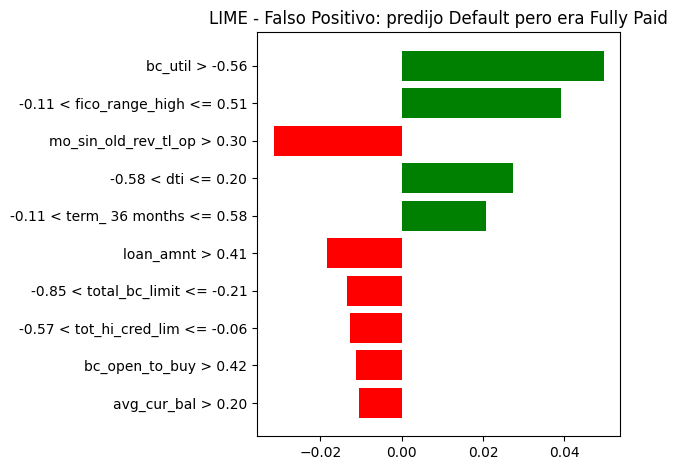

In [ ]:
import lime
import lime.lime_tabular

# Crear el explicador
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_top25,
    feature_names=feature_imp.head(25)["feature"].tolist(),
    class_names=["Fully Paid", "Charged Off"],
    mode="classification"
)

# Instancia mal clasificada
idx_fp = np.where((y_pred2 == 1) & (y_test.values == 0))[0][0]
exp1 = explainer.explain_instance(
    X_test_top25[idx_fp],
    grid_search2.best_estimator_.predict_proba,
    num_features=10
)
exp1.as_pyplot_figure()
plt.title("LIME - Falso Positivo: predijo Default pero era Fully Paid")
plt.tight_layout()
plt.show()

Para la instancia mal calificada, predijo Default pero era Fully Paid (Falso Positivo).Se puede observar que las variables `bc_util` y `fico_range_high` empujaron hacia Fully Paid mientras que `mo_sin_old_rev_tl_op`, `loan_amnt` y `avg_cur_bal` empujaron hacia Default, confundiendo al modelo. Esto permite ver que el modelo tiene limitaciones para perfiles donde el historial crediticio antiguo y montos altos pueden estar juntos y aun asi tener buenos indicadores de pago con buenos indicadores de pago 